#Uber Supply Demand Gap Analysis
##Project Objective 
Analyze Uber request data ton identify
demand-supply gaps, Peak hours, cancellation
Patterns and provide business
recommendations


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#Load Dataset

In [2]:
df = pd.read_csv("Uber Request Data.csv")
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25


#4 – Dataset Information


In [4]:
df.info()
df.shape
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,4016,2282
top,NaN,City,NaN,Trip Completed,15/07/16 19:19,13/07/16 8:53
freq,NaN,3507,NaN,2831,8,5
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


In [5]:
#Missing Values

In [5]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [ ]:
#Duplicate Values

In [ ]:
df.duplicated().sum()

In [ ]:
#7 – Convert Date Columns

In [6]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'])
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'])

In [ ]:
#8 – Create Hour Column

In [7]:
df['Request Hour'] = df['Request timestamp'].dt.hour
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request Hour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,2016-07-13 09:25:00,8


In [ ]:
#9 – Status Count

In [8]:
df['Status'].value_counts()

Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

In [ ]:
#11 – Hour-wise Requests

In [9]:
df['Request Hour'].value_counts().sort_index()

Request Hour
0      99
1      85
2      99
3      92
4     203
5     445
6     398
7     406
8     423
9     431
10    243
11    171
12    184
13    160
14    136
15    171
16    159
17    418
18    510
19    473
20    492
21    449
22    304
23    194
Name: count, dtype: int64

In [ ]:
12 – First Visualization

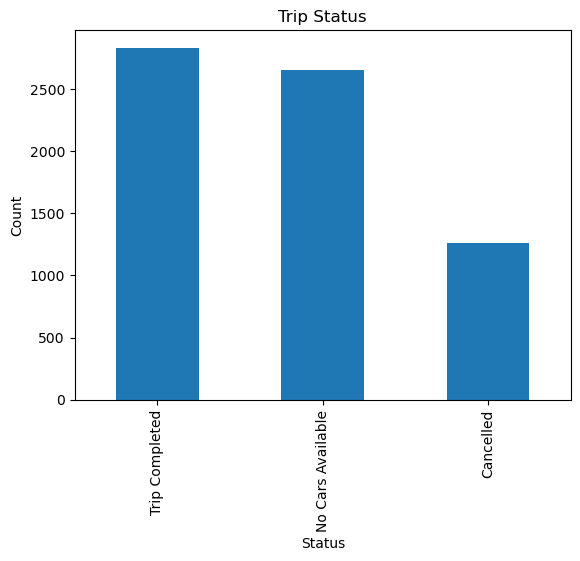

In [10]:
df['Status'].value_counts().plot(kind='bar')
plt.title("Trip Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# Conclusion

From the Exploratory Data Analysis (EDA) of the Uber Request Data, the following conclusions were observed:

- The dataset contains information about Uber requests, pickup points, trip status, and timestamps.
- The majority of requests are either "Trip Completed" or "No Cars Available".
- Demand varies throughout the day, with certain hours experiencing higher request volumes.
- The Airport and City pickup points show different demand and supply patterns.
- The analysis highlights a demand-supply gap during peak hours, leading to cancellations and unfulfilled requests.

## Recommendations

- Increase the number of available drivers during peak demand hours.
- Improve driver allocation between the Airport and the City.
- Use historical request data to forecast demand and optimize driver availability.
- Continuously monitor trip status to reduce cancellations and improve customer satisfaction.